In [4]:
import os
import sys
ROOT = ".." # Base directory relative to this notebook's location. Adjust if the notebook is moved
sys.path.append(ROOT)
CSV_DIR = os.path.join(ROOT, "csv")
STATS_DIR = os.path.join(CSV_DIR, "stats")
HIST_DATA_DIR = os.path.join(CSV_DIR, "historical-data")
JSON_DIR = os.path.join(ROOT, "json")
MAPS_DIR = os.path.join(ROOT, "maps")
GEO_DATA_PATH = os.path.join(JSON_DIR, "location-metadata.json")
import pandas as pd
import matplotlib.pyplot as plt
from src.station_time_series import (
    create_station_time_series,
    create_station_daily_averages,
)
from src.output_helpers import run_with_output_clear
from src.plot_helpers import plot_station_time_series

## Time series tables per station

### Creating time series tables

#### Daily low temperatures

In [5]:
TMIN_TIME_SERIES_PATH = os.path.join(STATS_DIR, "tmin_by_station.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
tmin_by_station = run_with_output_clear(
    create_station_time_series,
    source_path=HIST_DATA_DIR,
    export_path=TMIN_TIME_SERIES_PATH,
    metric="tmin",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    max_interpolation_days=10,
    end_date="2025-12-31"
)
display(tmin_by_station.head(3))
print("...")
display(tmin_by_station.tail(3))

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,2.4,-1.1,-0.1,4.6,-1.2,-0.1,3.9,2.9,-1.9,-5.7,...,1.6,1.1,-0.5,4.3,5.2,7.5,7.0,7.9,0.0,3.9
2015-01-02,6.1,-1.4,-1.2,4.5,-0.8,-1.5,4.0,3.1,0.0,-4.8,...,0.6,-0.6,2.3,2.5,3.9,8.1,8.9,9.5,-0.1,3.3
2015-01-03,8.6,-1.1,6.3,6.3,7.7,-0.2,5.0,6.1,2.0,-3.1,...,8.6,3.4,4.8,1.7,3.4,8.7,10.4,8.7,-0.7,5.3


...


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2025-12-29,NaN,5.6,5.7,8.5,3.9,5.2,7.7,8.9,4.3,6.0,...,4.7,4.7,1.3,7.6,8.5,9.6,8.8,8.2,5.9,6.8
2025-12-30,NaN,4.6,5.4,5.5,4.4,2.9,7.8,6.9,0.9,4.1,...,3.3,3.1,1.0,6.9,7.3,9.2,9.1,7.3,3.6,6.5
2025-12-31,NaN,1.1,0.6,3.9,-1.2,1.4,6.0,6.9,-0.6,-1.1,...,2.7,2.4,-0.2,4.8,6.9,9.5,9.4,8.8,3.3,5.0


#### Daily high temperatures

In [8]:
TMAX_TIME_SERIES_PATH = os.path.join(STATS_DIR, "tmax_by_station.csv")
tmax_by_station = run_with_output_clear(
    create_station_time_series,
    source_path=HIST_DATA_DIR,
    export_path=TMAX_TIME_SERIES_PATH,
    metric="tmax",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    max_interpolation_days=10,
    end_date="2025-12-31"
)
display(tmax_by_station.head(3))
print("...")
display(tmax_by_station.tail(3))

C928I_hist.csv: 2152 records processed (excluded)


C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,11.5,13.5,12.1,13.7,9.8,11.7,12.7,12.6,8.0,11.3,...,12.8,14.0,8.5,15.3,15.3,13.100000,11.8,13.2,14.1,15.3
2015-01-02,14.0,18.6,15.2,17.4,16.9,17.1,14.6,16.5,12.2,13.1,...,16.7,16.0,13.0,20.1,18.6,14.333333,15.0,15.6,16.3,15.9
2015-01-03,16.3,20.4,16.6,20.3,15.3,16.9,16.6,17.6,13.0,14.2,...,17.8,17.2,14.2,20.3,20.9,15.566667,17.3,16.3,18.6,16.2


...


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2025-12-29,NaN,14.6,12.6,15.6,9.1,11.4,13.7,12.8,11.2,9.9,...,15.9,16.3,8.3,14.9,15.1,17.6,16.9,17.1,14.4,13.7
2025-12-30,NaN,14.7,11.9,16.5,7.3,12.9,13.1,13.2,4.9,8.1,...,17.0,14.8,7.9,15.4,16.9,16.7,15.0,15.6,15.9,15.8
2025-12-31,NaN,14.4,13.2,14.7,10.3,12.1,13.5,13.1,8.2,9.0,...,12.9,13.9,7.4,12.6,14.8,12.7,11.5,12.9,13.9,14.7


#### Daily average temperatures

In [15]:
TMED_TIME_SERIES_PATH = os.path.join(STATS_DIR, "tmed_by_station.csv")
tmed_by_station = run_with_output_clear(
    create_station_time_series,
    source_path=HIST_DATA_DIR,
    export_path=TMED_TIME_SERIES_PATH,
    metric="tmed",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    max_interpolation_days=10,
    end_date="2025-12-31"
)
display(tmed_by_station.head(3))
print("...")
display(tmed_by_station.tail(3))

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,7.0,6.2,6.0,9.2,4.3,5.8,8.3,7.8,3.0,2.8,...,7.2,7.6,4.0,9.8,10.2,10.3,9.4,10.6,7.0,9.6
2015-01-02,10.0,8.6,7.0,11.0,8.0,7.8,9.3,9.8,6.1,4.2,...,8.6,7.7,7.6,11.3,11.2,11.2,12.0,12.6,8.1,9.6
2015-01-03,12.4,9.6,11.4,13.3,11.5,8.4,10.8,11.8,7.5,5.6,...,13.2,10.3,9.5,11.0,12.2,12.1,13.8,12.5,9.0,10.8


...


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2025-12-29,NaN,10.1,9.2,12.0,6.5,8.3,10.7,10.8,7.8,8.0,...,10.3,10.5,4.8,11.2,11.8,13.6,12.8,12.6,10.2,10.2
2025-12-30,NaN,9.6,8.6,11.0,5.8,7.9,10.4,10.0,2.9,6.1,...,10.2,9.0,4.4,11.2,12.1,13.0,12.0,11.4,9.8,11.2
2025-12-31,NaN,7.8,6.9,9.3,4.6,6.8,9.8,10.0,3.8,4.0,...,7.8,8.2,3.6,8.7,10.8,11.1,10.4,10.8,8.6,9.8


#### Daily precipitation (mm)

In [18]:
PREC_TIME_SERIES_PATH = os.path.join(STATS_DIR, "prec_by_station.csv")
prec_by_station = run_with_output_clear(
    create_station_time_series,
    source_path=HIST_DATA_DIR,
    export_path=PREC_TIME_SERIES_PATH,
    metric="prec",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    max_interpolation_days=10,
    end_date="2025-12-31"
)
display(prec_by_station.head(3))
print("...")
display(prec_by_station.tail(3))

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-02,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-03,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


...


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2025-12-29,NaN,0.0,0.4,0.2,1.2,0.6,0.6,0.6,0.0,0.2,...,0.2,0.4,5.6,3.8,3.4,0.0,0.6,7.2,4.8,3.2
2025-12-30,NaN,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.2,1.8,1.4,0.2,0.0,0.0,0.0,0.2,0.1
2025-12-31,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


#### Average wind speed

In [19]:
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]

In [21]:
VELM_TIME_SERIES_PATH = os.path.join(STATS_DIR, "velm_by_station.csv")
velm_by_station = run_with_output_clear(
    create_station_time_series,
    source_path=HIST_DATA_DIR,
    export_path=VELM_TIME_SERIES_PATH,
    metric="velmedia",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    max_interpolation_days=10,
    end_date="2025-12-31"
)
display(velm_by_station.head(3))
print("...")
display(velm_by_station.tail(3))

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)


,0009X,0016A,0042Y,0061X,0066X,0073X,0076,0092X,0106X,0114X,...,B569X,B605X,B614E,B644B,B662X,B760X,B780X,B800X,B825B,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2015-01-01,2.2,1.9,0.8,2.2,0.8,0.8,4.2,1.9,1.7,0.8,...,6.9,NaN,1.1,1.1,1.7,1.4,1.4,5.600000,3.9,1.7
2015-01-02,6.7,1.4,1.1,3.3,0.0,1.4,2.5,1.9,1.1,0.6,...,3.1,NaN,1.9,0.8,1.7,0.6,1.1,4.833333,1.9,1.9
2015-01-03,6.1,0.8,0.8,4.4,0.3,0.8,3.3,1.7,1.1,0.3,...,3.9,NaN,5.3,3.6,3.3,0.8,0.3,4.066667,2.2,6.4


...


,0009X,0016A,0042Y,0061X,0066X,0073X,0076,0092X,0106X,0114X,...,B569X,B605X,B614E,B644B,B662X,B760X,B780X,B800X,B825B,B954
fecha,,,,,,,,,,,,,,,,,,,,,
2025-12-29,NaN,1.4,NaN,0.8,0.8,0.6,2.5,1.4,0.8,0.6,...,2.8,0.8,0.6,0.6,0.8,0.3,NaN,NaN,1.1,3.1
2025-12-30,NaN,4.4,NaN,5.3,0.6,2.5,5.6,0.8,1.1,1.1,...,3.1,1.4,0.8,0.6,1.4,1.7,NaN,NaN,1.4,2.2
2025-12-31,NaN,1.1,NaN,1.1,0.8,0.8,3.9,1.7,1.7,0.8,...,5.0,1.4,1.4,1.7,1.9,0.6,NaN,NaN,4.2,3.3


### Loading saved time series tables

In [6]:
tmin_by_station = pd.read_csv(
    os.path.join(STATS_DIR, "metrics-by-station", "tmin_by_station.csv"),
    index_col="fecha",
    parse_dates=["fecha"],
)
print("Daily low temperatures:", tmin_by_station.shape)
print(f"{tmin_by_station.index.min().strftime("%Y-%m-%d")} to {tmin_by_station.index.max().strftime("%Y-%m-%d")}")

tmax_by_station = pd.read_csv(
    os.path.join(STATS_DIR, "metrics-by-station", "tmax_by_station.csv"),
    index_col="fecha",
    parse_dates=["fecha"],
)
print("Daily high temperatures:", tmax_by_station.shape)
print(f"{tmax_by_station.index.min().strftime("%Y-%m-%d")} to {tmax_by_station.index.max().strftime("%Y-%m-%d")}")

tmed_by_station = pd.read_csv(
    os.path.join(STATS_DIR, "metrics-by-station", "tmed_by_station.csv"),
    index_col="fecha",
    parse_dates=["fecha"],
)
print("Daily mean temperatures:", tmed_by_station.shape)
print(f"{tmed_by_station.index.min().strftime("%Y-%m-%d")} to {tmed_by_station.index.max().strftime("%Y-%m-%d")}")

prec_by_station = pd.read_csv(
    os.path.join(STATS_DIR, "metrics-by-station", "prec_by_station.csv"),
    index_col="fecha",
    parse_dates=["fecha"],
)
print("Daily precipitation:", prec_by_station.shape)
print(f"{prec_by_station.index.min().strftime("%Y-%m-%d")} to {prec_by_station.index.max().strftime("%Y-%m-%d")}")

velm_by_station = pd.read_csv(
    os.path.join(STATS_DIR, "metrics-by-station", "velm_by_station.csv"),
    index_col="fecha",
    parse_dates=["fecha"],
)
print("Daily average wind speed:", velm_by_station.shape)
print(f"{velm_by_station.index.min().strftime("%Y-%m-%d")} to {velm_by_station.index.max().strftime("%Y-%m-%d")}")

Daily low temperatures: (4018, 691)
2015-01-01 to 2025-12-31
Daily high temperatures: (4018, 691)
2015-01-01 to 2025-12-31
Daily mean temperatures: (4018, 691)
2015-01-01 to 2025-12-31
Daily precipitation: (4018, 685)
2015-01-01 to 2025-12-31
Daily average wind speed: (4018, 581)
2015-01-01 to 2025-12-31


### Calculating daily averages tables

In [8]:
TMIN_DAILY_AVERAGES_PATH = os.path.join(STATS_DIR, "daily_averages", "tmin_daily_averages.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
tmin_daily_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=TMIN_DAILY_AVERAGES_PATH,
    metric="tmin",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
)
display(tmin_daily_averages.head(3))
print("...")
display(tmin_daily_averages.tail(3))

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
1900-01-01,3.727273,2.650000,2.883333,6.016667,1.791667,2.050000,5.708333,5.800000,0.825000,-1.483333,...,4.741667,4.083333,0.733333,6.175000,7.191667,9.975000,8.875000,7.841667,4.091667,6.750000
1900-01-02,4.000000,3.325000,3.633333,6.108333,2.683333,1.416667,5.658333,5.166667,0.000000,-2.566667,...,5.400000,4.433333,2.736364,6.258333,6.958333,9.981818,9.033333,8.625000,3.690909,7.200000
1900-01-03,5.981818,4.241667,5.341667,7.316667,4.100000,3.675000,6.625000,6.333333,0.791667,-0.400000,...,7.108333,5.600000,3.625000,6.591667,7.463636,10.200000,9.575000,9.091667,4.291667,7.966667


...


,0009X,0016A,0034X,0042Y,0061X,0066X,0073X,0076,0092X,0106X,...,B644B,B662X,B684A,B760X,B780X,B800X,B825B,B860X,B908X,B954
fecha,,,,,,,,,,,,,,,,,,,,,
1900-12-29,5.89,4.136364,4.000000,7.418182,3.263636,3.690909,6.572727,7.200000,1.245455,0.227273,...,5.327273,4.46,1.772727,6.309091,7.109091,10.509091,9.600000,8.354545,4.563636,7.545455
1900-12-30,5.30,4.081818,4.327273,7.381818,3.281818,3.163636,6.818182,6.590909,1.381818,-0.827273,...,5.336364,4.92,1.890000,6.918182,7.581818,10.436364,9.936364,8.209091,4.020000,7.454545
1900-12-31,4.43,3.181818,3.154545,6.700000,3.054545,2.263636,6.700000,6.409091,1.300000,-1.372727,...,4.972727,4.01,1.733333,5.518182,6.445455,10.620000,9.718182,8.163636,3.000000,6.890909


In [9]:
TMAX_DAILY_AVERAGES_PATH = os.path.join(STATS_DIR, "daily_averages", "tmax_daily_averages.csv")
tmax_daily_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=TMAX_DAILY_AVERAGES_PATH,
    metric="tmax",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
)

print(tmax_daily_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)


C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
(365, 691)


In [10]:
PREC_DAILY_AVERAGES_PATH = os.path.join(STATS_DIR, "daily_averages", "prec_daily_averages.csv")
prec_daily_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=PREC_DAILY_AVERAGES_PATH,
    metric="prec",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
)

print(prec_daily_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)


C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
(365, 685)


In [11]:
TMED_DAILY_AVERAGES_PATH = os.path.join(STATS_DIR, "daily_averages", "tmed_daily_averages.csv")
tmed_daily_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=TMED_DAILY_AVERAGES_PATH,
    metric="tmed",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
)

print(tmed_daily_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)


C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
(365, 691)


In [12]:
VELM_DAILY_AVERAGES_PATH = os.path.join(STATS_DIR, "daily_averages", "velm_daily_averages.csv")
velm_daily_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=VELM_DAILY_AVERAGES_PATH,
    metric="velmedia",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
)

print(velm_daily_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)


C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
(365, 581)


### Loading daily averages tables

In [7]:
DA_DIR = os.path.join(STATS_DIR, "daily-averages-by-station")
tmin_daily_averages = pd.read_csv(os.path.join(DA_DIR, "tmin_daily_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmin: ", tmin_daily_averages.shape, f"{tmin_daily_averages.index.min().strftime("%m-%d")} → {tmin_daily_averages.index.max().strftime("%m-%d")}")
tmax_daily_averages = pd.read_csv(os.path.join(DA_DIR, "tmax_daily_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmax: ", tmax_daily_averages.shape, f"{tmax_daily_averages.index.min().strftime("%m-%d")} → {tmax_daily_averages.index.max().strftime("%m-%d")}")
tmed_daily_averages = pd.read_csv(os.path.join(DA_DIR, "tmed_daily_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmed: ", tmed_daily_averages.shape, f"{tmed_daily_averages.index.min().strftime("%m-%d")} → {tmed_daily_averages.index.max().strftime("%m-%d")}")
prec_daily_averages = pd.read_csv(os.path.join(DA_DIR, "prec_daily_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("prec: ", prec_daily_averages.shape, f"{prec_daily_averages.index.min().strftime("%m-%d")} → {prec_daily_averages.index.max().strftime("%m-%d")}")
velm_daily_averages = pd.read_csv(os.path.join(DA_DIR, "velm_daily_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("velm: ", velm_daily_averages.shape, f"{velm_daily_averages.index.min().strftime("%m-%d")} → {velm_daily_averages.index.max().strftime("%m-%d")}")

tmin:  (365, 691) 01-01 → 12-31
tmax:  (365, 691) 01-01 → 12-31
tmed:  (365, 691) 01-01 → 12-31
prec:  (365, 685) 01-01 → 12-31
velm:  (365, 581) 01-01 → 12-31


#### Daily temperature averages

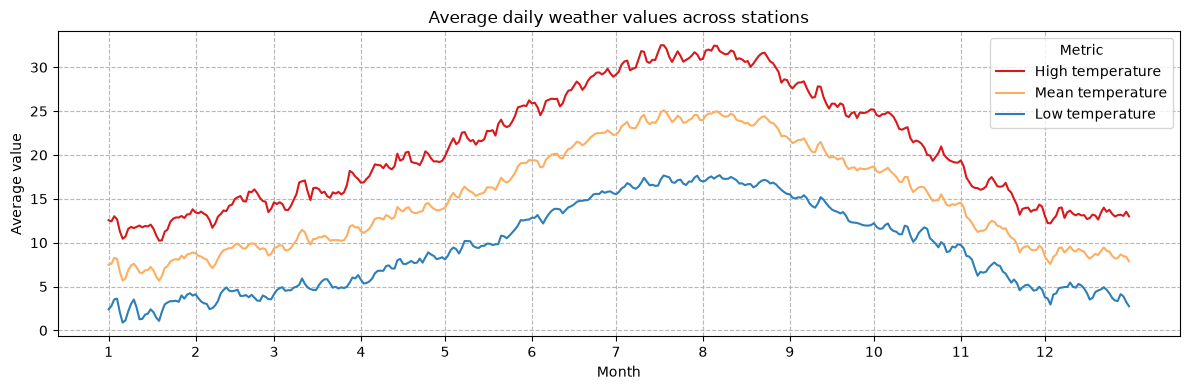

In [ ]:
daily_weather_averages = pd.DataFrame({
    "High temperature": tmax_daily_averages.mean(axis=1),
    "Mean temperature": tmed_daily_averages.mean(axis=1),
    "Low temperature": tmin_daily_averages.mean(axis=1)
})
daily_weather_averages.index = pd.to_datetime(daily_weather_averages.index).dayofyear

ax = daily_weather_averages.plot(
    figsize=(12, 4),
    linewidth=1.5,
    color={"Low temperature": "#2C7FB8", "Mean temperature": "#FDAE61", "High temperature": "#D7191C"},
)
month_starts = pd.to_datetime([f"2001-{month:02d}-01" for month in range(1, 13)]).dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(range(1, 13))
ax.set(xlabel="Month", ylabel="Average value", title="Average daily weather values across stations")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.9)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

#### Daily precipitation averages

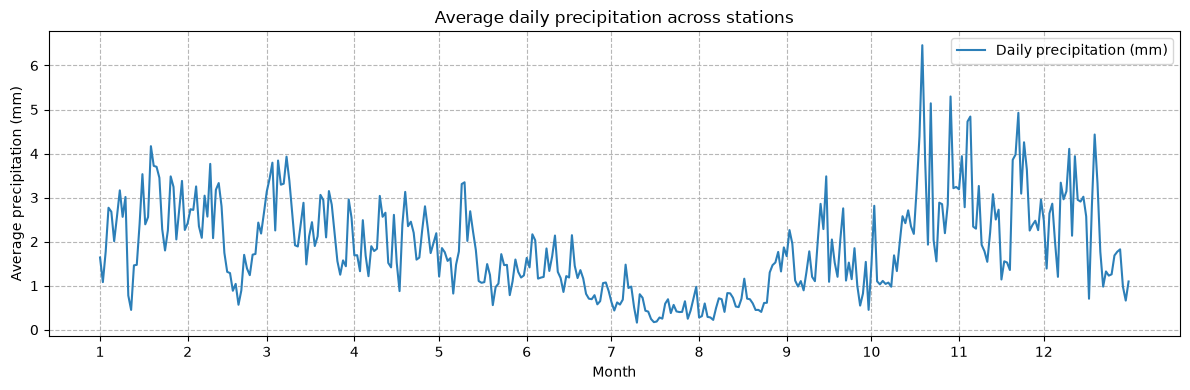

In [33]:
prec_daily_average = prec_daily_averages.mean(axis=1)
prec_daily_average.index = pd.to_datetime(prec_daily_average.index).dayofyear

ax = prec_daily_average.plot(
    figsize=(12, 4),
    linewidth=1.5,
    color="#2C7FB8",
    label="Daily precipitation (mm)",
 )
month_starts = pd.to_datetime([f"2001-{month:02d}-01" for month in range(1, 13)]).dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(range(1, 13))
ax.set(xlabel="Month", ylabel="Average precipitation (mm)", title="Average daily precipitation across stations")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.9)
ax.legend()
plt.tight_layout()
plt.show()

#### Daily wind averages

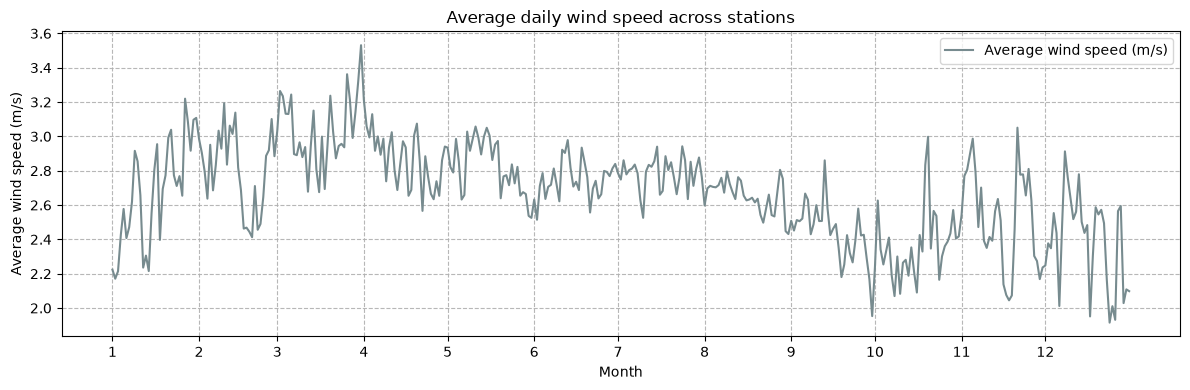

In [34]:
velm_daily_average = velm_daily_averages.mean(axis=1)
velm_daily_average.index = pd.to_datetime(velm_daily_average.index).dayofyear

ax = velm_daily_average.plot(
    figsize=(12, 4),
    linewidth=1.5,
    color="#778B8F",
    label="Average wind speed (m/s)",
 )
month_starts = pd.to_datetime([f"2001-{month:02d}-01" for month in range(1, 13)]).dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(range(1, 13))
ax.set(xlabel="Month", ylabel="Average wind speed (m/s)", title="Average daily wind speed across stations")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.9)
ax.legend()
plt.tight_layout()
plt.show()

### Calculating harmonized daily averages

In [4]:
TMIN_ROLLED_AVERAGES_PATH = os.path.join(STATS_DIR, "rolled-averages-by-station", "tmin_rolled_averages.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
tmin_rolled_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=TMIN_ROLLED_AVERAGES_PATH,
    metric="tmin",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    rolling_window_days=30
)

print("tmin_rolled_averages:", tmin_rolled_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
tmin_rolled_averages: (365, 691)


In [5]:
TMED_ROLLED_AVERAGES_PATH = os.path.join(STATS_DIR, "rolled-averages-by-station", "tmed_rolled_averages.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
tmed_rolled_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=TMED_ROLLED_AVERAGES_PATH,
    metric="tmed",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    rolling_window_days=30
)

print("tmed_rolled_averages:", tmed_rolled_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
tmed_rolled_averages: (365, 691)


In [6]:
TMAX_ROLLED_AVERAGES_PATH = os.path.join(STATS_DIR, "rolled-averages-by-station", "tmax_rolled_averages.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
tmax_rolled_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=TMAX_ROLLED_AVERAGES_PATH,
    metric="tmax",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    rolling_window_days=30
)

print("tmax_rolled_averages:", tmax_rolled_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
tmax_rolled_averages: (365, 691)


In [16]:
PREC_ROLLED_AVERAGES_PATH = os.path.join(STATS_DIR, "rolled-averages-by-station", "prec_rolled_averages.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
prec_rolled_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=PREC_ROLLED_AVERAGES_PATH,
    metric="prec",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    rolling_window_days=90
)

print("prec_rolled_averages:", prec_rolled_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
prec_rolled_averages: (365, 685)


In [18]:
VELM_ROLLED_AVERAGES_PATH = os.path.join(STATS_DIR, "rolled-averages-by-station", "velm_rolled_averages.csv")
provinces_to_exclude = ["LAS PALMAS", "STA. CRUZ DE TENERIFE", "SANTA CRUZ DE TENERIFE",
                        "CEUTA", "MELILLA", "BALEARES", "ILLES BALEARES"]
velm_rolled_averages = run_with_output_clear(
    create_station_daily_averages,
    source_path=HIST_DATA_DIR,
    export_path=VELM_ROLLED_AVERAGES_PATH,
    metric="velmedia",
    provinces_to_exclude=provinces_to_exclude,
    provinces_to_include=None,
    rolling_window_days=90
)

print("velm_rolled_averages:", velm_rolled_averages.shape)

C928I_hist.csv: 2152 records processed (excluded)
C929I_hist.csv: 4148 records processed (excluded)
C939T_hist.csv: 4152 records processed (excluded)
velm_rolled_averages: (365, 581)


### Loading harmonized daily averages tables

In [19]:
DRA_DIR = os.path.join(STATS_DIR, "rolled-averages-by-station")
tmin_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "tmin_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmin: ", tmin_rolled_averages.shape, f"{tmin_rolled_averages.index.min().strftime("%m-%d")} → {tmin_rolled_averages.index.max().strftime("%m-%d")}")
tmax_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "tmax_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmax: ", tmax_rolled_averages.shape, f"{tmax_rolled_averages.index.min().strftime("%m-%d")} → {tmax_rolled_averages.index.max().strftime("%m-%d")}")
tmed_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "tmed_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmed: ", tmed_rolled_averages.shape, f"{tmed_rolled_averages.index.min().strftime("%m-%d")} → {tmed_rolled_averages.index.max().strftime("%m-%d")}")
prec_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "prec_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("prec: ", prec_rolled_averages.shape, f"{prec_rolled_averages.index.min().strftime("%m-%d")} → {prec_rolled_averages.index.max().strftime("%m-%d")}")
velm_rolled_averages = pd.read_csv(os.path.join(DRA_DIR, "velm_rolled_averages.csv"), index_col="fecha", parse_dates=["fecha"],)
print("velm: ", velm_rolled_averages.shape, f"{velm_rolled_averages.index.min().strftime("%m-%d")} → {velm_rolled_averages.index.max().strftime("%m-%d")}")

tmin:  (365, 691) 01-01 → 12-31
tmax:  (365, 691) 01-01 → 12-31
tmed:  (365, 691) 01-01 → 12-31
prec:  (365, 685) 01-01 → 12-31
velm:  (365, 581) 01-01 → 12-31


#### Daily temperature averages (30-day rolling window)

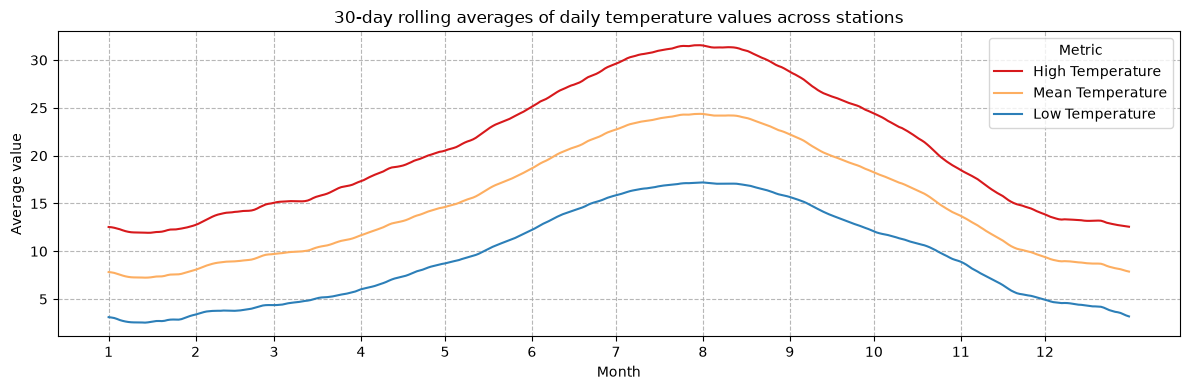

In [30]:
daily_rolled_temp_averages = pd.DataFrame({
    "High Temperature": tmax_rolled_averages.mean(axis=1),
    "Mean Temperature": tmed_rolled_averages.mean(axis=1),
    "Low Temperature": tmin_rolled_averages.mean(axis=1),
})
daily_rolled_temp_averages.index = pd.to_datetime(daily_rolled_temp_averages.index).dayofyear

ax = daily_rolled_temp_averages.plot(
    figsize=(12, 4),
    linewidth=1.5,
    color={"High Temperature": "#D7191C", "Mean Temperature": "#FDAE61", "Low Temperature": "#2C7FB8",},
)
month_starts = pd.to_datetime([f"2001-{month:02d}-01" for month in range(1, 13)]).dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(range(1, 13))
ax.set(xlabel="Month", ylabel="Average value", title="30-day rolling averages of daily temperature values across stations")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.9)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

#### Daily precipitation averages (90-day rolling window)

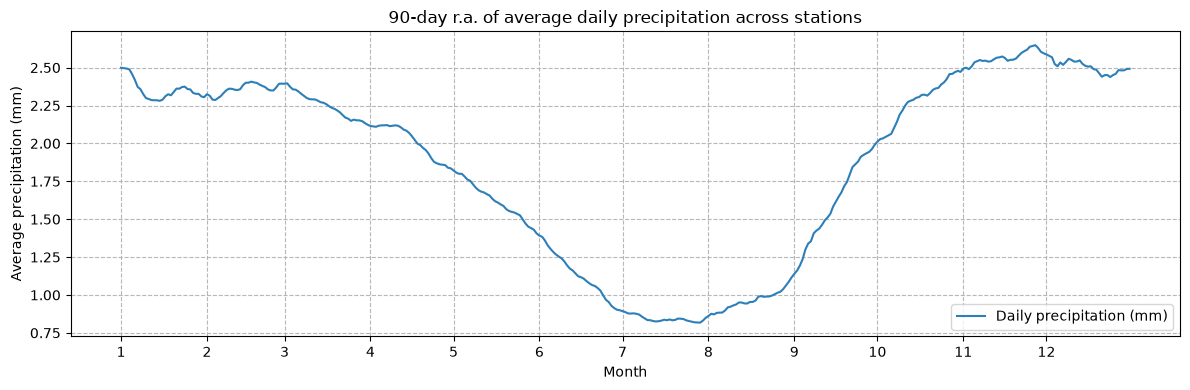

In [27]:
prec_rolled_average = prec_rolled_averages.mean(axis=1)
prec_rolled_average.index = pd.to_datetime(prec_rolled_average.index).dayofyear

ax = prec_rolled_average.plot(
    figsize=(12, 4),
    linewidth=1.5,
    color="#2C7FB8",
    label="Daily precipitation (mm)",
 )
month_starts = pd.to_datetime([f"2001-{month:02d}-01" for month in range(1, 13)]).dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(range(1, 13))
ax.set(xlabel="Month", ylabel="Average precipitation (mm)", title="90-day r.a. of average daily precipitation across stations")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.9)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Daily mean wind speed averages (90-day rolling window)

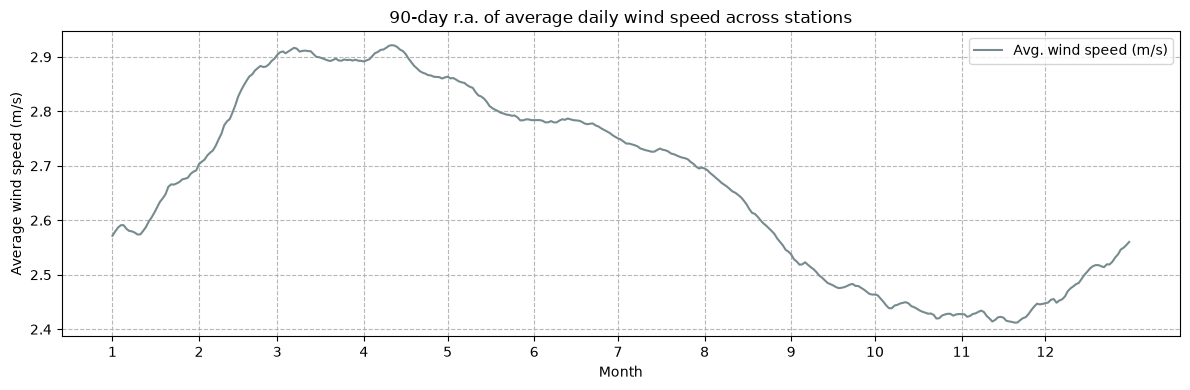

In [26]:
velm_rolled_average = velm_rolled_averages.mean(axis=1)
velm_rolled_average.index = pd.to_datetime(velm_rolled_average.index).dayofyear

ax = velm_rolled_average.plot(
    figsize=(12, 4),
    linewidth=1.5,
    color="#778B8F",
    label="Avg. wind speed (m/s)",
 )
month_starts = pd.to_datetime([f"2001-{month:02d}-01" for month in range(1, 13)]).dayofyear
ax.set_xticks(month_starts)
ax.set_xticklabels(range(1, 13))
ax.set(xlabel="Month", ylabel="Average wind speed (m/s)", title="90-day r.a. of average daily wind speed across stations")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.9)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Trend plots

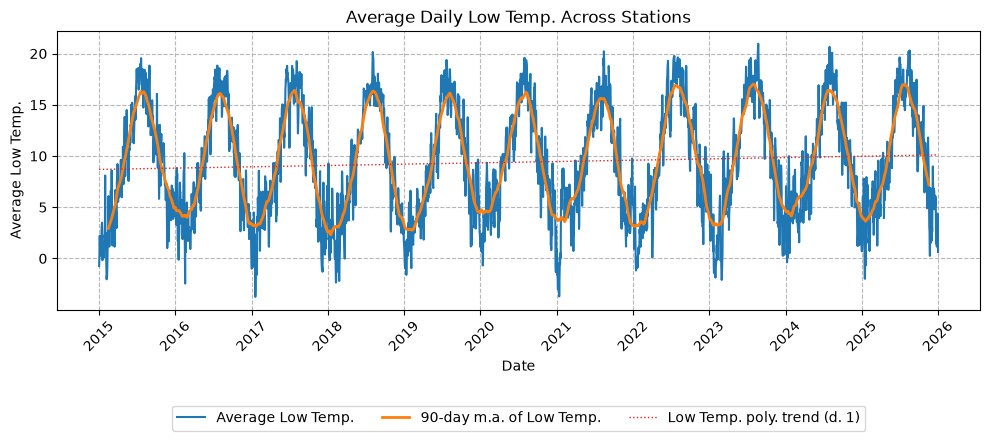

Average yearly change: +0.129 °C/year


In [36]:
tmin_by_station = os.path.join(STATS_DIR, "metrics-by-station", "tmin_by_station.csv")
series_df = pd.read_csv(tmin_by_station, index_col="fecha", parse_dates=["fecha"])

plot_result = plot_station_time_series(
    series_df,
    trend_line=1,
    moving_average_days=90,
    figsize=(10, 6),
    metric_name="Low Temp.",
)
plt.show()

linear_slope = plot_result["trend_coefficients"][0]
print(f"Average yearly change: {linear_slope:+.3f} °C/year")

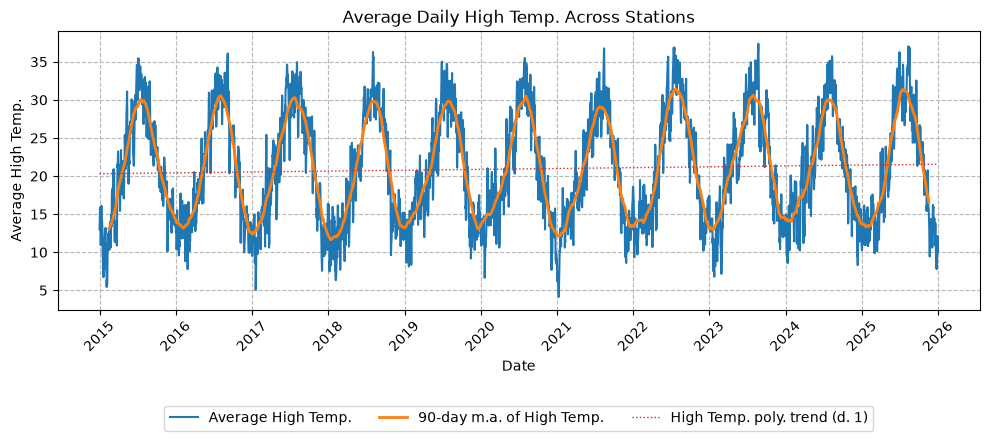

Average yearly change: +0.113 °C/year


In [37]:
tmax_by_station = os.path.join(STATS_DIR, "metrics-by-station", "tmax_by_station.csv")
series_df = pd.read_csv(tmax_by_station, index_col="fecha", parse_dates=["fecha"])

plot_result = plot_station_time_series(
    series_df,
    trend_line=1,
    moving_average_days=90,
    figsize=(10, 6),
    metric_name="High Temp.",
)
plt.show()

linear_slope = plot_result["trend_coefficients"][0]
print(f"Average yearly change: {linear_slope:+.3f} °C/year")

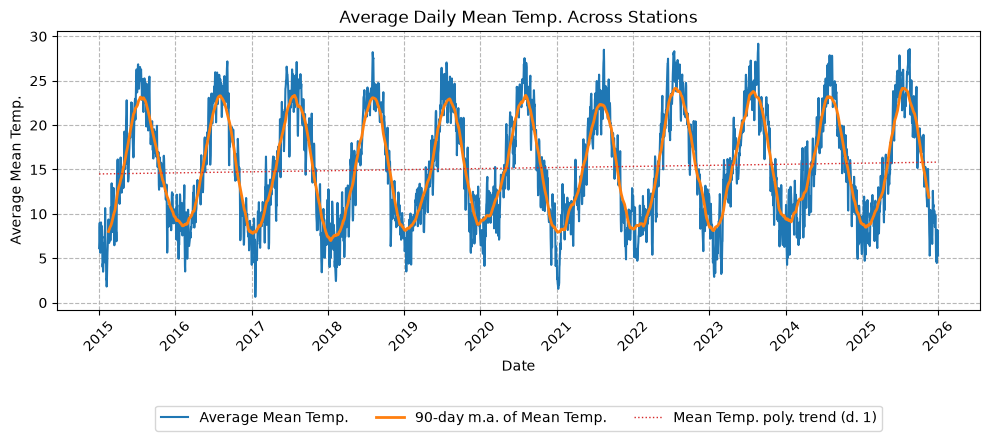

Average yearly change: +0.121 °C/year


In [38]:
tmed_by_station = os.path.join(STATS_DIR, "metrics-by-station", "tmed_by_station.csv")
series_df = pd.read_csv(tmed_by_station, index_col="fecha", parse_dates=["fecha"])

plot_result = plot_station_time_series(
    series_df,
    trend_line=1,
    moving_average_days=90,
    figsize=(10, 6),
    metric_name="Mean Temp.",
)
plt.show()

linear_slope = plot_result["trend_coefficients"][0]
print(f"Average yearly change: {linear_slope:+.3f} °C/year")

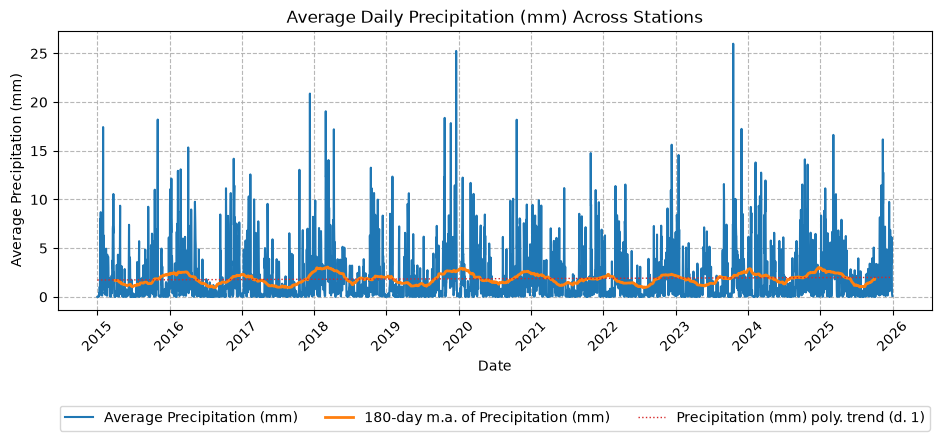

Average yearly change: +0.024 mm/year


In [39]:
prec_by_station = os.path.join(STATS_DIR, "metrics-by-station", "prec_by_station.csv")
series_df = pd.read_csv(prec_by_station, index_col="fecha", parse_dates=["fecha"])

plot_result = plot_station_time_series(
    series_df,
    trend_line=1,
    moving_average_days=180,
    figsize=(10, 6),
    metric_name="Precipitation (mm)",
)
plt.show()

linear_slope = plot_result["trend_coefficients"][0]
print(f"Average yearly change: {linear_slope:+.3f} mm/year")

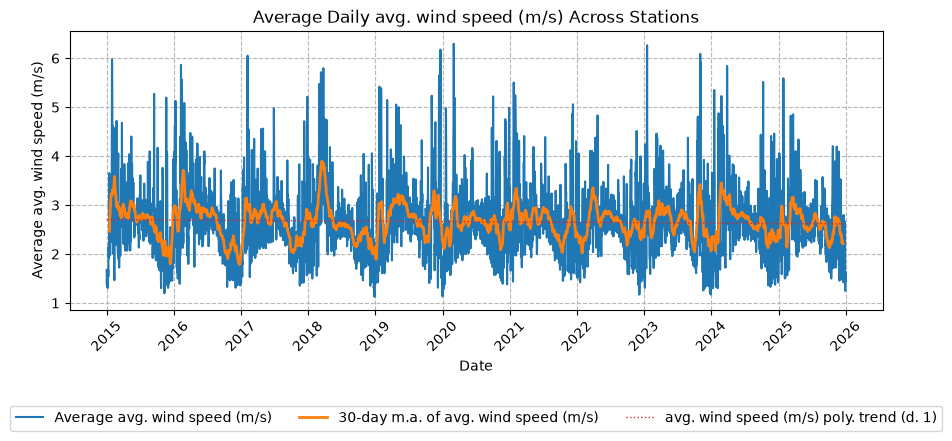

Average yearly change: -0.008 m/s/year


In [40]:
velm_by_station = os.path.join(STATS_DIR, "metrics-by-station", "velm_by_station.csv")
series_df = pd.read_csv(velm_by_station, index_col="fecha", parse_dates=["fecha"])

plot_result = plot_station_time_series(
    series_df,
    trend_line=1,
    moving_average_days=30,
    figsize=(10, 6),
    metric_name="avg. wind speed (m/s)",
)
plt.show()

linear_slope = plot_result["trend_coefficients"][0]
print(f"Average yearly change: {linear_slope:+.3f} m/s/year")

### Maps

In [41]:
master_data = pd.read_json(GEO_DATA_PATH).T.reset_index().rename(columns={"index": "idema"})
display(master_data)

,idema,ubi,lon,lat,alt
0,0009X,ALFORJA,0.963335,41.213892,406.0
1,0016A,REUS AEROPUERTO,1.163611,41.145,71.0
2,0034X,VALLS,1.260838,41.293053,233.0
3,0042Y,TARRAGONA FAC. GEOGRAFIA,1.249167,41.123892,55.0
4,0061X,PONTONS,1.519269,41.417052,632.0
...,...,...,...,...,...
817,5047E,BAZA CRUZ ROJA,-2.734995,37.505829,785.0
818,6332Y,CARBONERAS - FARO MESA ROLDÁN,-1.906944,36.942222,222.0
819,2789H,POZUELO DE TABARA,-5.909007,41.785554,711.0
820,2873X,BARBADILLO,-5.779717,40.903607,817.0


______________

In [42]:
station_geo_data = (
    master_data[["idema", "lat", "lon", "alt"]]
    .rename(columns={"idema": "station_id"})
    .copy()
)
station_geo_data[["lat", "lon", "alt"]] = station_geo_data[["lat", "lon", "alt"]].apply(
    pd.to_numeric, errors="coerce"
)
station_geo_data.to_csv(os.path.join(CSV_DIR, "station_geo_data.csv"), index=False)
display(station_geo_data)

,station_id,lat,lon,alt
0,0009X,41.213892,0.963335,406.0
1,0016A,41.145000,1.163611,71.0
2,0034X,41.293053,1.260838,233.0
3,0042Y,41.123892,1.249167,55.0
4,0061X,41.417052,1.519269,632.0
...,...,...,...,...
817,5047E,37.505829,-2.734995,785.0
818,6332Y,36.942222,-1.906944,222.0
819,2789H,41.785554,-5.909007,711.0
820,2873X,40.903607,-5.779717,817.0
